# OTF Scan --- Data Load (DR1 + DR2a + DR2b + DR3a + DR3b + DR4a + DR4b + DR5a + DR5b + DR6a)

Load OTF scan dumps from `data/lab04/streaming/DR*/`,
apply fftshift, medfilt RFI flagging, frequency-switch, and build a
gridded HI map in galactic coordinates.

In [1]:
import sys; sys.path.insert(0, '..')

# Ensure local utils/ is found before labs/02/utils/
import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting  # applies rcParams
from ugradiolab.plotting import SS_FINE
from plotters import plot_spectra_grid, plot_heatmap, plot_survey_mollweide
from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                   compute_R_for_dumps, compute_cell_W, build_heatmap)

from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load all scan dumps

In [2]:
STREAMING_DIR = Path('../../../data/lab04/streaming')
DATA_RELEASES = ['DR1', 'DR2a', 'DR2b', 'DR3a', 'DR3b', 'DR4a', 'DR4b', 'DR5a', 'DR5b', 'DR6a']

scan_dirs = []
for dr in DATA_RELEASES:
    dr_dir = STREAMING_DIR / dr
    if not dr_dir.exists():
        continue
    found = sorted(dr_dir.glob('scan_r*_c*'))
    print(f'{dr}: {len(found)} cells')
    scan_dirs.extend(found)

print(f'Total: {len(scan_dirs)} cells')

# Collect all dumps
records = []
for d in scan_dirs:
    dr_label = d.parent.name
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'dr': dr_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Parse row/col from target name
import re
for r in records:
    m = re.match(r'scan_r(\d+)_c(\d+)', r['target'])
    if m:
        r['row'] = int(m.group(1))
        r['col'] = int(m.group(2))
    else:
        r['row'] = -1
        r['col'] = -1

rows = sorted(set(r['row'] for r in records if r['row'] >= 0))
cols = sorted(set(r['col'] for r in records if r['col'] >= 0))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

for dr in DATA_RELEASES:
    n_dr = sum(1 for r in records if r['dr'] == dr)
    if n_dr > 0:
        print(f'  {dr}: {n_dr} dumps')
print(f'Grid: {len(rows)} rows x {len(cols)} cols')
print(f'Cal: {n_cal}, Science: {n_sci}')
print(f'LO frequencies: {lo_unique} MHz')

DR1: 153 cells
DR2a: 14 cells
DR2b: 95 cells
DR3a: 179 cells
DR3b: 80 cells
DR4a: 226 cells
DR4b: 40 cells
DR5a: 49 cells
DR5b: 241 cells
DR6a: 12 cells
Total: 1089 cells
9103 total dumps loaded
  DR1: 1225 dumps
  DR2a: 432 dumps
  DR2b: 758 dumps
  DR3a: 1461 dumps
  DR3b: 641 dumps
  DR4a: 1826 dumps
  DR4b: 321 dumps
  DR5a: 407 dumps
  DR5b: 1935 dumps
  DR6a: 97 dumps
Grid: 15 rows x 51 cols
Cal: 56, Science: 9047
LO frequencies: [1420.0, 1421.0] MHz


## 2. fftshift + Stokes I + RFI flagging

In [3]:
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr00'] + r['corr11']

# RFI flagging: scipy.signal.medfilt + MAD, flags both positive and
# negative outliers (spikes and dropouts).  The median filter also
# catches the DC bin spike and LO leakage channels, so no explicit
# masking is needed — those channels fall within the edge trim anyway.
RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz
RFI flagged: 769333 samples across 9103 dumps


Outlier dump filter (spectral shape): removed 35 dumps
  (flag if >20% of channels deviate >10% from group median)
Remaining: 9068 dumps


/tmp/ipykernel_368472/3984293243.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


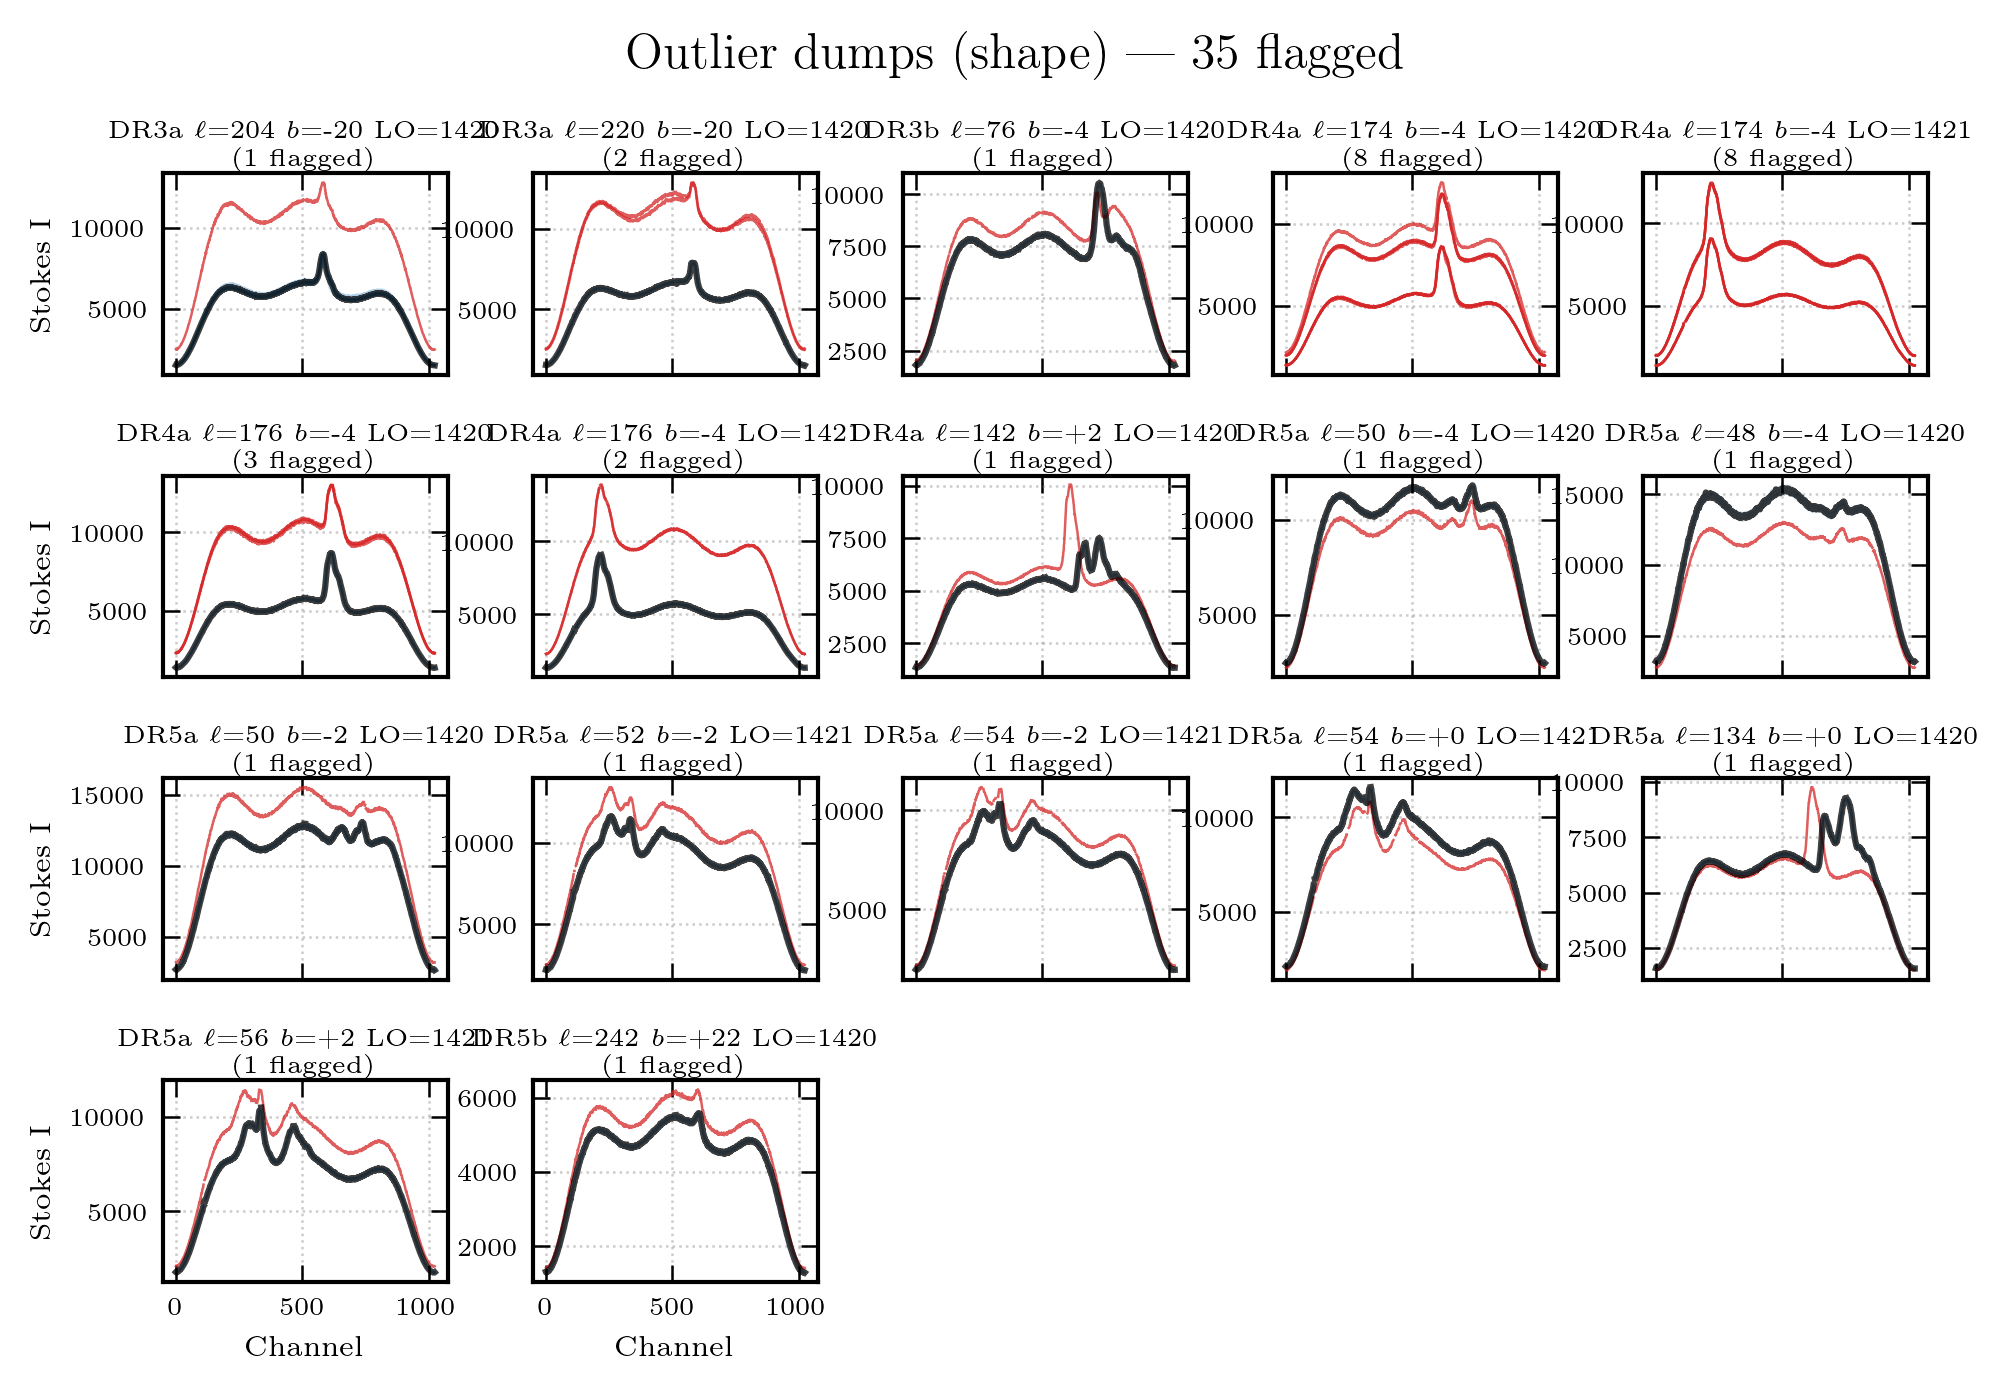

In [4]:
# --- Outlier science dump filter (spectral shape comparison) ---
# For each (DR, cell, LO) group, compute the median spectrum and flag
# dumps whose spectral shape deviates significantly.  This catches gain
# ripple, wrong pointing, partial RFI contamination, and broadband
# glitches -- all of which alter the shape, not just the amplitude.

import warnings
import astropy.coordinates as ac
import astropy.units as u_ast
from collections import defaultdict

SHAPE_DEV_THRESH = 0.10   # flag channels >10% from median ratio
SHAPE_FRAC_THRESH = 0.20  # flag dump if >20% of channels are bad

outlier_records = flag_outlier_dumps(records, SHAPE_DEV_THRESH, SHAPE_FRAC_THRESH)
n_outlier_removed = len(outlier_records)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {n_outlier_removed} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

# --- Diagnostic: overplot all dumps per (cell, LO) with outliers highlighted ---
import math

all_sci = [r for r in records if r.get('row', -1) >= 0 and not r['noise_on']]
all_sci += outlier_records
outlier_paths = set(id(r) for r in outlier_records)

def _resolve_lb(group):
    r0 = group[0]
    c = ac.SkyCoord(ra=r0['ra'] * u_ast.deg, dec=r0['dec'] * u_ast.deg, frame='icrs')
    return round(c.galactic.l.deg), round(c.galactic.b.deg)

plot_groups = defaultdict(list)
for r in all_sci:
    plot_groups[(r['dr'], r['target'], r['lo_mhz'])].append(r)

groups_with_outliers = {
    k: v for k, v in plot_groups.items()
    if any(id(r) in outlier_paths for r in v)
}

if groups_with_outliers:
    NCOLS = 5
    keys = sorted(groups_with_outliers.keys())
    n_panels = len(keys)
    nrows = math.ceil(n_panels / NCOLS)
    ROW_HEIGHT_IN = 1.2
    rows_per_page = max(1, int(plotting.A4_USABLE_HEIGHT_IN / ROW_HEIGHT_IN))
    channels = np.arange(NFFT)

    for page_start_row in range(0, nrows, rows_per_page):
        page_end_row = min(page_start_row + rows_per_page, nrows)
        page_nrows = page_end_row - page_start_row
        page_start_idx = page_start_row * NCOLS
        page_end_idx = min(page_end_row * NCOLS, n_panels)

        fig, axes = plt.subplots(
            page_nrows, NCOLS,
            figsize=(plotting.TEXTWIDTH_IN, ROW_HEIGHT_IN * page_nrows),
            gridspec_kw={'hspace': 0.5, 'wspace': 0.3},
        )
        axes = np.atleast_2d(axes)

        for i_in_page, i_global in enumerate(range(page_start_idx, page_end_idx)):
            dr, target, lo = keys[i_global]
            group = groups_with_outliers[keys[i_global]]
            ri, ci = divmod(i_in_page, NCOLS)
            ax = axes[ri, ci]

            good = [r['stokes_I'] for r in group if id(r) not in outlier_paths]
            if good:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore', RuntimeWarning)
                    med_spec = np.nanmedian(np.array(good), axis=0)
                ax.plot(channels, med_spec, lw=plotting.LW_STANDARD,
                        color='k', alpha=plotting.ALPHA_STANDARD,
                        label='median', zorder=10)

            for r in group:
                is_outlier = id(r) in outlier_paths
                ax.plot(channels, r['stokes_I'],
                        lw=plotting.LW_FINE,
                        color='C3' if is_outlier else 'C0',
                        alpha=plotting.ALPHA_STANDARD if is_outlier else plotting.ALPHA_EXTRA_LIGHT,
                        zorder=5 if is_outlier else 1)

            gl, gb = _resolve_lb(group)
            n_out = sum(1 for r in group if id(r) in outlier_paths)
            ax.set_title(
                rf'{dr} $\ell$={gl} $b$={gb:+d} LO={lo:.0f}'
                f'\n({n_out} flagged)',
                fontsize=plotting.TICK_SIZE - 4, pad=2,
            )
            ax.tick_params(labelsize=plotting.TICK_SIZE - 4)
            if ri < page_nrows - 1:
                ax.set_xticklabels([])
            if ci == 0:
                ax.set_ylabel('Stokes I', fontsize=plotting.TICK_SIZE - 3)

        n_on_page = page_end_idx - page_start_idx
        for i_in_page in range(n_on_page, page_nrows * NCOLS):
            ri, ci = divmod(i_in_page, NCOLS)
            axes[ri, ci].set_visible(False)

        for ci in range(min(NCOLS, n_on_page)):
            axes[-1, ci].set_xlabel('Channel', fontsize=plotting.TICK_SIZE - 3)

        page_num = page_start_row // rows_per_page + 1
        total_pages = math.ceil(nrows / rows_per_page)
        label = f'Outlier dumps (shape) --- {n_outlier_removed} flagged'
        if total_pages > 1:
            label += f' ({page_num}/{total_pages})'
        fig.suptitle(label, fontsize=plotting.EMPHASIS_SIZE)
        fig.tight_layout()
        plt.show()
else:
    print('No outlier dumps to plot.')

## 2a. Pointing summary

In [ ]:
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast

# Compute galactic coords and per-pointing stats from already-loaded records
pointing_stats = {}  # (l, b) -> {dr: ..., n_captured, bad_pixels, unusable}

for r in records:
    if r['row'] < 0:
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    gl, gb = round(c.galactic.l.deg), round(c.galactic.b.deg)
    key = (gl, gb)

    if key not in pointing_stats:
        pointing_stats[key] = {'n_captured': 0, 'bad_pixels': 0, 'unusable': 0}

    pointing_stats[key]['n_captured'] += 1

    # Count bad pixels in this dump's stokes_I (already masked)
    n_bad = int(np.sum(np.isnan(r['stokes_I'])))
    pointing_stats[key]['bad_pixels'] += n_bad

    # Unusable if >50% channels are NaN
    if n_bad > NFFT // 2:
        pointing_stats[key]['unusable'] += 1

# Build DataFrame
rows_df = []
for (gl, gb), stats in sorted(pointing_stats.items()):
    rows_df.append({
        'l': gl, 'b': gb,
        'captured': stats['n_captured'],
        'bad_pixels_total': stats['bad_pixels'],
        'unusable_dumps': stats['unusable'],
    })

df = pd.DataFrame(rows_df).set_index(['l', 'b'])

n_pointings = len(df)
n_unusable_any = (df['unusable_dumps'] > 0).sum()
print(f'Unique pointings: {n_pointings}')
print(f'Total dumps: {df["captured"].sum()}')
print(f'Pointings with any unusable dumps: {n_unusable_any}')
print(f'Mean bad pixels per dump: {df["bad_pixels_total"].sum() / df["captured"].sum():.0f} / {NFFT}')
print()
df


## 3. Frequency-switched profiles per cell

For each cell, pair dumps at the two LO frequencies and compute
`R = (I1 - I2) / I2`.

**LSR correction**: Each dump's topocentric velocity is shifted to the
kinematic LSR frame (solar motion 20 km/s toward 18h +30deg B1900).
Per-DR results stay in the topocentric frame (intra-session shift < 0.01 km/s).
Combined results interpolate each DR onto a common LSR velocity grid before
averaging, correcting for Earth's orbital motion between sessions.

In [ ]:
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime
from collections import defaultdict

EDGE_TRIM_MHZ = 0.256

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)  # topocentric

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')

# --- Assign galactic coords ---
for r in records:
    if r['row'] < 0:
        r['gl'], r['gb'] = None, None
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

# --- LSR velocity correction ---
# v_LSR = v_topo + v_corr, where v_corr = heliocentric + solar motion to LSRK.
# Compute one correction per (DR, cell) group -- all dumps in a group are
# taken within minutes, so share the same correction to < 0.01 km/s.
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        r['v_corr_lsr'] = 0.0
        continue
    cell_dr_groups[(r['dr'], r['gl'], r['gb'])].append(r)

for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    v_corr = vlsr_correction(r0['ra'], r0['dec'], mean_t)
    for r in group:
        r['v_corr_lsr'] = v_corr

sci_vcorr = [r['v_corr_lsr'] for r in records
             if r.get('gl') is not None and not r['noise_on']]
mean_vcorr = np.mean(sci_vcorr)
print(f'  Range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
      f'(mean {mean_vcorr:.2f})')

# Common LSR velocity grid for combined results
v_lsr_overlap = v_overlap + mean_vcorr
print(f'Velocity (LSR):  [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

# Per-DR LSR corrections
for dr in DATA_RELEASES:
    dr_vc = [r['v_corr_lsr'] for r in records
             if r.get('dr') == dr and r.get('gl') is not None and not r['noise_on']]
    if dr_vc:
        print(f'  {dr}: v_corr = {np.mean(dr_vc):+.2f} km/s '
              f'(shift vs ref: {np.mean(dr_vc) - mean_vcorr:+.2f})')

# --- All unique (l, b) pointings ---
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

# --- Build results ---
cell_results = {}           # per-DR, topocentric (for per-DR plots)
cell_results_combined = {}  # combined, LSR-corrected

for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]

    # Combined with LSR correction
    result = compute_R_for_dumps(sci_dumps, lo1, lo2, overlap_mask, v_overlap,
                                 lsr_correct=True, v_lsr_grid=v_lsr_overlap)
    if result is not None:
        cell_results_combined[(gl, gb)] = result

    # Per DR (topocentric -- intra-session shift is negligible)
    for dr in DATA_RELEASES:
        dr_dumps = [r for r in sci_dumps if r['dr'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

for dr in DATA_RELEASES:
    n = sum(1 for k in cell_results if k[0] == dr)
    print(f'  {dr}: {n} cells')
print(f'  Combined (LSR): {len(cell_results_combined)} cells')

## 4. HI map

Velocity-integrated R over the full overlap bandwidth (256 kHz trimmed edges).

W = Sigma R(v) x Deltav [km/s]

In [ ]:
# Channel width in km/s
dv_kms = np.abs(np.median(np.diff(v_overlap)))
n_overlap_ch = overlap_mask.sum()

print(f'dv = {dv_kms:.3f} km/s per channel')
print(f'Overlap channels: {n_overlap_ch}')
print(f'Total velocity range: {n_overlap_ch * dv_kms:.1f} km/s')

# --- Per-DR flat maps ---
for dr in DATA_RELEASES:
    dr_results = {(l, b): v for (d, l, b), v in cell_results.items() if d == dr}
    if not dr_results:
        continue
    gl, gb, vals = compute_cell_W(dr_results, dv_kms)
    fig, ax = plot_heatmap(gl, gb, vals,
                           cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
                           cmap="inferno",
                           title=f'{dr} --- {len(vals)} cells')
    plt.show()

# --- Combined Mollweide projection ---
MOLL_CENTER_L = 120.0

gl_all, gb_all, W_all = compute_cell_W(cell_results_combined, dv_kms)
fig, ax = plot_survey_mollweide(
    gl_all, gb_all, W_all,
    center_l=MOLL_CENTER_L,
    cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
    cmap="inferno",
    marker_size=SS_FINE,
    title=f'Combined HI map --- {len(W_all)} cells',
)
plt.show()

In [ ]:
# --- HI map overlaid on candidate survey footprints ---
from matplotlib.patches import Rectangle
import matplotlib as mpl
import astropy.coordinates as ac
import astropy.units as u_ast

LEO_LAT_FP = 37.9183
MOLL_CENTER_FP = MOLL_CENTER_L  # 120 deg, same as combined map above
MOLL_SEAM_FP = (MOLL_CENTER_FP + 180) % 360
MIN_ALT_FP, MAX_ALT_FP = 17.0, 83.0
AZ_MIN_FP, AZ_MAX_FP = 7.0, 348.0

# Candidate survey footprints (from 01_scan_plan)
projects_raw_fp = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4, 'C0'),
    ('Gal. plane (wide)',         0, 360,  -20,  20, 'C0'),
    ('Great circle l=220/40',   218, 222,  -90,  90, 'C1'),
    ('Great circle l=40/220',    38,  42,  -90,  90, 'C1'),
    ('Great circle l=130/310',  128, 132,  -90,  90, 'C2'),
    ('Great circle l=310/130',  308, 312,  -90,  90, 'C2'),
    ('NCP',                     105, 160,   15,  50, 'C3'),
    ('Orion-Eridanus',          160, 220,  -70, -10, 'C4'),
    ('North Polar Spur',        210, 380,    0,  90, 'C5'),
    ('HVC',                      60, 180,   20,  60, 'C6'),
    ('Magellanic Stream',        60, 110,  -90, -30, 'C7'),
]

def _normalize_l(l):
    return l % 360

def _crosses_seam(l_min, l_max):
    span = l_max - l_min
    if span >= 360:
        return True
    ln = _normalize_l(l_min)
    lx = _normalize_l(l_max)
    if ln <= lx:
        return ln < MOLL_SEAM_FP < lx
    else:
        return MOLL_SEAM_FP > ln or MOLL_SEAM_FP < lx

projects_fp = []
for name, l_min, l_max, b_min, b_max, color in projects_raw_fp:
    if l_max - l_min >= 360:
        projects_fp.append((name, MOLL_SEAM_FP + 0.5, MOLL_SEAM_FP + 180, b_min, b_max, color))
        projects_fp.append((name, MOLL_SEAM_FP + 180, MOLL_SEAM_FP + 359.5, b_min, b_max, color))
    elif _crosses_seam(l_min, l_max):
        projects_fp.append((name, l_min, MOLL_SEAM_FP - 0.5, b_min, b_max, color))
        projects_fp.append((name, MOLL_SEAM_FP + 0.5, l_max, b_min, b_max, color))
    else:
        projects_fp.append((name, l_min, l_max, b_min, b_max, color))

def _wrap_l(l):
    l = l - MOLL_CENTER_FP
    if l > 180: l -= 360
    if l < -180: l += 360
    return l

def _make_rect(l_min, l_max, b_min, b_max):
    n = 50
    wl_min, wl_max = _wrap_l(l_min), _wrap_l(l_max)
    if wl_min > wl_max:
        return None
    l_bot = np.linspace(wl_min, wl_max, n)
    l_top = np.linspace(wl_max, wl_min, n)
    b_left = np.linspace(b_min, b_max, n)
    b_right = np.linspace(b_max, b_min, n)
    ls = np.concatenate([l_bot, np.full(n, wl_max), l_top, np.full(n, wl_min)])
    bs = np.concatenate([np.full(n, b_min), b_left, np.full(n, b_max), b_right])
    return np.column_stack([np.deg2rad(ls), np.deg2rad(bs)])

# Never-observable mask (HA sweep, same as 01_scan_plan)
l_dense = np.arange(-179.5, 180.5, 1.0)
b_dense = np.arange(-89.5, 90.5, 1.0)
L_dense, B_dense = np.meshgrid(l_dense, b_dense)
L_true = (L_dense + MOLL_CENTER_FP) % 360

gc_grid = ac.SkyCoord(l=L_true.ravel() * u_ast.deg, b=B_dense.ravel() * u_ast.deg,
                      frame='galactic')
dec_rad = np.deg2rad(gc_grid.transform_to(ac.ICRS()).dec.deg).reshape(L_dense.shape)
lat_rad = np.deg2rad(LEO_LAT_FP)

ha_steps = np.deg2rad(np.arange(0, 360, 1))
observable = np.zeros(L_dense.shape, dtype=bool)
alt_lo_r, alt_hi_r = np.deg2rad(MIN_ALT_FP), np.deg2rad(MAX_ALT_FP)
az_lo_r, az_hi_r = np.deg2rad(AZ_MIN_FP), np.deg2rad(AZ_MAX_FP)

for ha in ha_steps:
    sin_alt = (np.sin(lat_rad) * np.sin(dec_rad)
               + np.cos(lat_rad) * np.cos(dec_rad) * np.cos(ha))
    alt = np.arcsin(np.clip(sin_alt, -1, 1))
    cos_az_num = np.sin(dec_rad) - np.sin(lat_rad) * sin_alt
    cos_az_den = np.cos(lat_rad) * np.cos(alt)
    with np.errstate(invalid='ignore', divide='ignore'):
        cos_az = np.clip(cos_az_num / cos_az_den, -1, 1)
    az = np.arccos(cos_az)
    az = np.where(np.sin(ha) > 0, 2 * np.pi - az, az)
    observable |= ((alt >= alt_lo_r) & (alt <= alt_hi_r)
                   & (az >= az_lo_r) & (az <= az_hi_r))

inacc_mask = (~observable).astype(float)

# --- Plot ---
fig, _ax = plotting.landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, alpha=plotting.ALPHA_EXTRA_LIGHT)

# Galactic plane
l_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_line, np.zeros_like(l_line), 'k-', lw=plotting.LW_FINE, alpha=0.3)

# Inaccessible mask
mpl.rcParams['hatch.color'] = 'red'
mpl.rcParams['hatch.linewidth'] = 0.5
ax.contourf(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
            levels=[0.5, 1.5], colors=['red'], alpha=0.08, hatches=['///'], zorder=1)
ax.contour(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
           levels=[0.5], colors=['red'], linewidths=0.6, alpha=0.4, zorder=2)
mpl.rcParams['hatch.color'] = 'black'

# Project footprints
plotted_labels = set()
for name, l_min, l_max, b_min, b_max, color in projects_fp:
    verts = _make_rect(l_min, l_max, b_min, b_max)
    if verts is not None:
        label = name if name not in plotted_labels else None
        poly = plt.Polygon(verts, alpha=plotting.ALPHA_EXTRA_LIGHT,
                           facecolor=color, edgecolor=color,
                           lw=plotting.LW_FINE, linestyle='--', label=label)
        ax.add_patch(poly)
        if label:
            plotted_labels.add(name)

# HI data overlay
gl_wrap = np.array([_wrap_l(l) for l in gl_all])
sc = ax.scatter(np.deg2rad(gl_wrap), np.deg2rad(gb_all),
                c=W_all, cmap='inferno', s=SS_FINE,
                edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.05)
cbar.set_label(r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
               fontsize=plotting.LABEL_SIZE)

# Tick labels
tick_locs = np.arange(-150, 180, 30)
tick_labels_fp = [f'{int((t + MOLL_CENTER_FP) % 360)}deg' for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels_fp, fontsize=plotting.LEGEND_SIZE)

# Reference labels
for ld, name in [(0, 'GC'), (90, 'l=90'), (180, 'AC'), (270, 'l=270')]:
    lp = _wrap_l(ld)
    if -180 <= lp <= 180:
        ax.annotate(name, (np.deg2rad(lp), np.deg2rad(-8)),
                    fontsize=plotting.LEGEND_SIZE, ha='center', va='top', color='gray')

ax.set_title(f'HI survey coverage on candidate footprints (centered l={MOLL_CENTER_FP:.0f}deg)',
             fontsize=plotting.EMPHASIS_SIZE)

# Legend
legend_proxy = Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.1,
                          edgecolor='red', hatch='///')
handles, labels = ax.get_legend_handles_labels()
handles.append(legend_proxy)
labels.append('Never observable')
ax.legend(handles, labels, fontsize=plotting.LEGEND_SIZE - 1, loc='lower right', ncol=2)

fig.tight_layout()
plt.show()

## 5. All spectra per DR

In [ ]:
# for dr in DATA_RELEASES:
#     dr_spectra = {(l, b): cell_results[(d, l, b)]['R_overlap']
#                   for (d, l, b) in cell_results if d == dr}
#     if not dr_spectra:
#         continue
#     result = plot_spectra_grid(v_overlap, dr_spectra,
#                                ncols=5,
#                                color="C0",
#                                title=f'{dr} --- {len(dr_spectra)} pointings')
#     figs = result if isinstance(result, list) else [result]
#     for f in figs:
#         plt.show()

## 5a. Telescope pointing trace per DR

Scan pattern in galactic coordinates and alt/az Mollweide showing the
actual telescope path through each dump, colored by time order.

In [ ]:
from matplotlib.patches import Circle
from astropy.time import Time as AstroTime
import matplotlib.dates as mdates

HPBW_DEG = 3.4
LEO_LON = -122.1067

for dr in DATA_RELEASES:
    dr_recs = sorted([r for r in records if r['dr'] == dr and r['row'] >= 0],
                     key=lambda r: r['time'])
    if len(dr_recs) < 2:
        continue

    gl_dr = np.array([r['gl'] for r in dr_recs], dtype=float)
    gb_dr = np.array([r['gb'] for r in dr_recs], dtype=float)
    alt_dr = np.array([r['alt'] for r in dr_recs])
    az_dr = np.array([r['az'] for r in dr_recs])
    t_dr = np.array([r['time'] for r in dr_recs])

    # Compute actual LST for each dump
    lst_hrs = np.array([
        AstroTime(t, format='unix').sidereal_time(
            'apparent', longitude=LEO_LON * u_ast.deg
        ).hour for t in t_dr
    ])

    # --- Galactic scan pattern with beam circles colored by LST ---
    fig, ax = plt.subplots(figsize=(plotting.TEXTWIDTH_IN, 4))
    cmap = plt.cm.viridis

    vmin, vmax = lst_hrs.min(), lst_hrs.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i in range(len(gl_dr)):
        c = cmap(norm(lst_hrs[i]))
        beam = Circle((gl_dr[i], gb_dr[i]), HPBW_DEG / 2,
                       fill=False, edgecolor=c,
                       alpha=plotting.ALPHA_EXTRA_LIGHT, lw=plotting.LW_FINE)
        ax.add_patch(beam)

    sc = ax.scatter(gl_dr, gb_dr, c=lst_hrs, cmap='viridis',
                    s=plotting.SS_FINE, edgecolors='none',
                    alpha=plotting.ALPHA_STANDARD, zorder=5,
                    vmin=vmin, vmax=vmax)
    ax.plot(gl_dr, gb_dr, lw=plotting.LW_FINE * 0.3, color='k',
            alpha=0.15, zorder=0)
    ax.set_xlabel(r'$\ell$ [deg]', fontsize=plotting.LABEL_SIZE)
    ax.set_ylabel(r'$b$ [deg]', fontsize=plotting.LABEL_SIZE)
    ax.set_title(f'{dr} scan pattern (HPBW = {HPBW_DEG}deg)', fontsize=plotting.EMPHASIS_SIZE)
    ax.set_aspect('equal')
    ax.grid(True, **plotting.GRID_STYLE)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label('LST [hr]')
    fig.tight_layout()
    plt.show()

    # --- Alt/Az Mollweide trace colored by LST ---
    az_moll = np.where(az_dr > 180, az_dr - 360, az_dr)

    fig, _ax = plotting.landscapewidth_figure(5)
    _ax.remove()
    ax = fig.add_subplot(111, projection='mollweide')
    ax.grid(True, **{k: v for k, v in plotting.GRID_STYLE.items() if k != 'color'},
            color=plotting.NEUTRAL_COLOR)

    az_line = np.linspace(-np.pi, np.pi, 500)
    ax.plot(az_line, np.full_like(az_line, np.deg2rad(17)),
            lw=plotting.LW_LIGHT, ls='--', color='C3', alpha=plotting.ALPHA_LIGHT)
    for az_lim in [7, 348]:
        az_l = az_lim if az_lim <= 180 else az_lim - 360
        ax.axvline(np.deg2rad(az_l), lw=plotting.LW_LIGHT, ls='--',
                   color='C1', alpha=plotting.ALPHA_LIGHT)

    ax.plot(np.deg2rad(az_moll), np.deg2rad(alt_dr),
            lw=plotting.LW_FINE * 0.5, color='k', alpha=0.2, zorder=0)
    sc = ax.scatter(np.deg2rad(az_moll), np.deg2rad(alt_dr),
                    c=lst_hrs, cmap='viridis', s=plotting.SS_FINE,
                    edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5,
                    vmin=vmin, vmax=vmax)

    for azd, name in [(0, 'N'), (90, 'E'), (180, 'S'), (-90, 'W')]:
        ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)),
                    fontsize=plotting.TICK_SIZE, ha='center', va='top',
                    fontweight='bold', color=plotting.NEUTRAL_COLOR)

    ax.set_title(f'{dr} alt/az trace', fontsize=plotting.EMPHASIS_SIZE)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label('LST [hr]')
    fig.tight_layout()
    plt.show()

    print(f'{dr}: {len(dr_recs)} dumps, LST {lst_hrs.min():.1f}-{lst_hrs.max():.1f} hr, '
          f'alt [{alt_dr.min():.0f}-{alt_dr.max():.0f}], az [{az_dr.min():.0f}-{az_dr.max():.0f}]')

## 6. Summary

In [ ]:
all_times = [r['time'] for r in records]
t0 = dt.datetime.fromtimestamp(min(all_times), tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(max(all_times), tz=dt.UTC)
wall = max(all_times) - min(all_times)

# Recompute counts after outlier removal
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

print(f'Scan grid:  {len(rows)} x {len(cols)} = {len(cell_results)} cells with data')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({n_cal} cal + {n_sci} science)')
print(f'Channels:   {NFFT} (dnu={df_khz:.2f} kHz)')

## 7. Update survey manifest

Write the manifest file with per-pointing completeness status.
Push this file to the observation Pi so `observe_otf.py` can skip complete cells.

In [ ]:
from manifest import write_manifest, pairs_target

# Build pointing dump counts from records (already have gl, gb assigned)
manifest_pointings = {}
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    key = (r['gl'], r['gb'])
    if key not in manifest_pointings:
        manifest_pointings[key] = {'n_1420': 0, 'n_1421': 0}
    if r['lo_mhz'] == 1420.0:
        manifest_pointings[key]['n_1420'] += 1
    elif r['lo_mhz'] == 1421.0:
        manifest_pointings[key]['n_1421'] += 1

MANIFEST_PATH = Path('../survey_manifest.json')
write_manifest(manifest_pointings, MANIFEST_PATH)

# Show incomplete cells
from manifest import read_manifest
pointings = read_manifest(MANIFEST_PATH)
incomplete = {lb: info for lb, info in pointings.items() if not info['complete']}
if incomplete:
    print(f'\nIncomplete cells ({len(incomplete)}):')
    print(f'  {"l":>4} {"b":>4} {"pairs":>5} {"target":>6} {"need":>5}')
    for (l, b), info in sorted(incomplete.items()):
        need = info['target'] - info['n_pairs']
        print(f'  {l:>4} {b:>+4} {info["n_pairs"]:>5} {info["target"]:>6} {need:>5}')
else:
    print('\nAll cells complete!')